# Portfolio and Benchmark setup

This notebook demonstrates the creation of portfolios & public indices reconstruction as benchmark and then backtesting them together.

### Objective
We want to reconstruct the **S&P 500** index using float-adjusted market-cap methodology so that we can replicate the SPDR S&P 500 ETF (SPY) and the index level (^GSPC) for the year 2025 using our own backtesting engine. We cross-check the reconstruction against the tradable SPY ETF and the ^GSPC price index, and we go one step further by defining our own investment thesis — a concentrated **Magnificent 8** book — to see whether we can beat the broad market.

All reference data (index constituents + float-adjusted shares outstanding) and all end-of-day prices are sourced from **Refinitiv (LSEG)**.

### Overview

This notebook covers:
- Reconstruction of the S&P 500 index (`.SPX` constituents) via Refinitiv and its daily positional holdings
- Loading float-adjusted shares outstanding from Refinitiv for market-cap weighting
- Creation of an investable SPY ETF portfolio to validate the S&P 500 reconstruction
- Creation of an investable ^GSPC index-level portfolio as a second cross-check
- A concentrated Magnificent 8 thesis portfolio (all S&P 500 constituents)
- Back testing all four portfolios together with market-weighted & equal-weighted approaches

### Prerequisites

Before running this notebook, ensure you have:
- Required Python packages installed (incl. `lseg.data` / `refinitiv.data`)
- A valid Refinitiv LSEG session (the loader opens it automatically)
- Database credentials stored in keyring
- Appropriate database schema and functions
- ipython-sql to run sql in the notebook

## 1. Environment Setup and Path Configuration

Set up the Python environment by configuring import paths and ensuring juypyter notebook can access custom modules in the project structure.

In [1]:
import sys
import os

import pandas as pd

# Get the current notebook's directory and go up to parent
current_dir = os.getcwd()
parent_dir = os.path.dirname(os.path.dirname(current_dir))

if parent_dir not in sys.path:
    sys.path.append(parent_dir)

print(f"Current directory: {current_dir}")
print(f"Added to path: {parent_dir}")
data_eng_path = os.path.join(parent_dir, 'data_engineering')
files_path = os.path.join(parent_dir, 'toolkit\\files')
print(f"Data engineering folder exists: {os.path.exists(data_eng_path)}")
print(f"Files folder exists: {os.path.exists(files_path)}")

Current directory: c:\SourceCode\InvestmentManagement\toolkit\notebooks
Added to path: c:\SourceCode\InvestmentManagement
Data engineering folder exists: True
Files folder exists: True


## 2. Database Connection and Module Imports

Establish database connectivity and import required modules for data engineering and market data retrieval.<br> 
It includes retry logic for database connection failures and sets up SQL magic commands for inline SQL execution.


In [2]:
from data_engineering.database import database

# Open the Refinitiv LSEG desktop session (requires LSEG Workspace running)
import lseg.data as ld
ld.open_session()  # idempotent

# Live DB connection via OS keyring (db/uid/pwd in 'ihub_sql_connection')
engine, connection, conn_str, session = database.get_db_connection()
print('DB connection:', 'OK')

%load_ext sql
%sql $conn_str
from sqlalchemy import text


Database connection successful.
DB connection: OK


In [3]:
from data_engineering.eod_data import refinitiv, yahoo, tiingo

## 3. Backtest Period Definition

Setting the analysis period for the backtest. These dates define the time window for all portfolio performance calculations and risk metrics.

In [4]:
start_date = "2025-01-01"
end_date = "2026-08-31"


In [5]:
# Reset the backtest staging tables before rebuilding.
# Pure-Python (not %%sql) so we avoid ipython-sql batch splitting, and no bound
# parameters (which trip SQLAlchemy 2.0's Connection.execute arg count). Tables
# absent in this deployment (currency_rates, analytics.portfolio_analytics) are
# detected via OBJECT_ID and skipped.
from sqlalchemy import text

_TRUNCATE_TARGETS = [
    "dbo.portfolio",
    "dbo.portfolio_holdings",
    "dbo.market_data",
    "dbo.currency_rates",
    "analytics.portfolio_analytics",
    "dbo.security_fundamentals",
    "reference.index_constituents",
    "dbo.security_master",
    "dbo.security_vendor_xref",
]
_truncated = []
with engine.begin() as conn:
    for t in _TRUNCATE_TARGETS:
        sch, tbl = t.split(".")
        oid = conn.execute(text("SELECT OBJECT_ID('[" + sch + "].[" + tbl + "]')")).scalar()
        if oid is not None:
            conn.execute(text("TRUNCATE TABLE [" + sch + "].[" + tbl + "]"))
            _truncated.append(t)
print("Truncated:", _truncated if _truncated else "no applicable tables")

# ── Idempotency gate ─────────────────────────────────────────────────
# When False, the expensive Refinitiv-backed cells (6 = constituents + float
# shares, 21 = EOD price pull) are SKIPPED on rerun so you can re-execute any
# other cell (plots, risk, weights) without redoing the ~15-25 min data load.
# Set FORCE_RELOAD = False to force those cells to run even if their target
# tables already hold data. A normal top-to-bottom run always reloads because
# this cell truncates every staging table first; this flag only matters when
# you rerun a SUBSET of cells.
FORCE_RELOAD = True

def _has_rows(engine, table, schema="dbo"):
    from sqlalchemy import text as _t
    with engine.connect() as _conn:
        oid = _conn.execute(_t(f"SELECT OBJECT_ID('[{schema}].[{table}]')")).scalar()
        if oid is None:
            return False
        return _conn.execute(_t(f"SELECT TOP 1 1 FROM [{schema}].[{table}]")).scalar() is not None


Truncated: ['dbo.portfolio', 'dbo.portfolio_holdings', 'dbo.market_data', 'dbo.security_fundamentals', 'reference.index_constituents', 'dbo.security_master', 'dbo.security_vendor_xref']


##### Load S&P 500 constituents & float-adjusted shares from Refinitiv
Reconstruct `.SPX` membership for the backtest window, enrich it with our `security_master` identifiers, and write it to `reference.index_constituents` under `index_id = 2`. We also pull float-adjusted shares outstanding from Refinitiv — the source for market-cap weighting later on.

Note: `enrich_with_security_master` hardcodes `index_id = 1`, so we override it to `2` here. The loader now resolves `security_id` via `security_vendor_xref.vendor_ticker` (exact RIC -> normalized RIC -> ISIN/SEDOL/CUSIP/FIGI) and KEEPS `Constituent RIC`, so `build_float_adjusted_shares` correctly receives the enriched frame.

In [6]:
# IDEMPOTENT: skip the ~20-min Refinitiv constituent + float-share pull if
# reference.index_constituents already has our index_id=2 rows (unless forced).
RUN_CELL6 = FORCE_RELOAD or not _has_rows(engine, 'index_constituents', 'reference')
if not RUN_CELL6:
    print('[cell 6] index_constituents already populated (index_id=2) -- SKIP (set FORCE_RELOAD=True to reload)')
else:
    import lseg.data as ld
    from data_engineering.index_constituents import refinitiv as ic_ref

    SP500_INDEX_ID = 2

    index_df = ic_ref.build_index_constituents('.SPX', start_date, end_date)

    asset_attributes = ld.get_data(
        universe=index_df['Constituent RIC'].drop_duplicates().tolist(),
        fields=[
            'TR.CommonName', 'TR.ISIN', 'TR.SEDOL', 'TR.CUSIP',
            'TR.ExchangeCountryCode', 'TR.Currency', 'TR.GICSSector',
            'TR.GICSIndustryGroup', 'TR.GICSIndustry', 'TR.ExchangeTicker',
            'TR.ExchangeCode',
        ],
    )

    joined = index_df.merge(
        asset_attributes, left_on='Constituent RIC', right_on='Instrument', how='left'
    )

    df_enriched = ic_ref.enrich_with_security_master(joined)
    df_enriched['index_id'] = SP500_INDEX_ID  # override hardcoded index_id = 1

    # A) Drop non-equity / futures RICs that Refinitiv wrongly resolves as
    # .SPX constituents (e.g. 'ES' = S&P 500 E-mini futures, 'NQ'/'YM'/'RTY'
    # futures, 'VIX'). They carry real prices and inflate the cap-weighted
    # recon (ES alone was ~4.2% weight) and are not real index members.
    _BAD_TICKERS = {'ES', 'NQ', 'VIX', 'YM', 'RTY'}
    _before = len(df_enriched)
    df_enriched = df_enriched[
        ~df_enriched['exchange_ticker'].astype(str).str.upper().isin(_BAD_TICKERS)
    ]
    print(f'[cell 6] dropped {_before - len(df_enriched)} non-equity/futures '
          f'ticker(s) from .SPX constituents (e.g. ES E-mini)')

    # index_constituents requires exchange_ticker, start_date, upsert_by (NOT NULL)
    assert not df_enriched['exchange_ticker'].isna().any(), 'exchange_ticker has nulls'
    assert not df_enriched['start_date'].isna().any(), 'start_date has nulls'
    unresolved = int(df_enriched['security_id'].isna().sum())
    print(f"RIC->security_id coverage: {len(df_enriched) - unresolved}/{len(df_enriched)} "
          f"({unresolved} unresolved)")
    database.write_index_constituents(df_enriched, session)

    # Float-adjusted shares outstanding -> market-cap weighting source.
    # Pass the ENRICHED frame (needs Constituent RIC + exchange_ticker + security_id).
    metrics_df = ic_ref.build_float_adjusted_shares(df_enriched, start=start_date, end=end_date)
    metrics_df['metric_type'] = 'shares_outstanding'  # match the reader's expectation
    assert not metrics_df['security_id'].isna().any(), 'shares metric has unresolved security_id'
    assert not metrics_df['effective_date'].isna().any(), 'effective_date has nulls'
    database.write_security_fundamentals(metrics_df, session)

    print(f"Wrote {len(df_enriched)} S&P 500 constituent rows "
          f"(index_id={SP500_INDEX_ID}) and {len(metrics_df)} "
          f"shares-outstanding rows from Refinitiv.")


Database connection successful.
[constituents] creating 540 new security_master rows for unresolved normalized RICs
Wrote 1 vendor xref rows for Refinitiv.
Wrote 1 vendor xref rows for Refinitiv.
Wrote 1 vendor xref rows for Refinitiv.
Wrote 1 vendor xref rows for Refinitiv.
Wrote 1 vendor xref rows for Refinitiv.
Wrote 1 vendor xref rows for Refinitiv.
Wrote 1 vendor xref rows for Refinitiv.
Wrote 1 vendor xref rows for Refinitiv.
Wrote 1 vendor xref rows for Refinitiv.
Wrote 1 vendor xref rows for Refinitiv.
Wrote 1 vendor xref rows for Refinitiv.
Wrote 1 vendor xref rows for Refinitiv.
Wrote 1 vendor xref rows for Refinitiv.
Wrote 1 vendor xref rows for Refinitiv.
Wrote 1 vendor xref rows for Refinitiv.
Wrote 1 vendor xref rows for Refinitiv.
Wrote 1 vendor xref rows for Refinitiv.
Wrote 1 vendor xref rows for Refinitiv.
Wrote 1 vendor xref rows for Refinitiv.
Wrote 1 vendor xref rows for Refinitiv.
Wrote 1 vendor xref rows for Refinitiv.
Wrote 1 vendor xref rows for Refinitiv.
Wrot

## 4. Portfolio Creation - Magnificent 8 Tech Stocks

Creating the first portfolio containing concentrated positions in the "Magnificent 8" technology stocks.

In [7]:
# IDEMPOTENT: get-or-create portfolio by short_name (rerun will not duplicate it).
from sqlalchemy import text as _t
_short = 'MAG8'
_name = 'Backtest Mag 8'
_ptype = 'Portfolio'
_ex = session.execute(_t(
    "SELECT port_id FROM dbo.portfolio WHERE portfolio_short_name=:s AND portfolio_type=:t"
), {'s': _short, 't': _ptype}).scalar()
if _ex is not None:
    new_port_id = int(_ex)
    print(f'[portfolio] reused {_short} (port_id={new_port_id})')
else:
    res = session.execute(_t(
        "INSERT INTO dbo.portfolio (portfolio_short_name, portfolio_name, portfolio_type, is_active) "
        "OUTPUT INSERTED.port_id VALUES (:s, :n, :t, 1)"
    ), {'s': _short, 'n': _name, 't': _ptype})
    new_port_id = int(res.fetchone()[0])
    session.commit()
    print(f'[portfolio] created {_short} (port_id={new_port_id})')


[portfolio] created MAG8 (port_id=1)


Confirming the Magnificent 8 portfolio was successfully created in the database.

In [8]:
%%sql
SELECT * FROM [dbo].[portfolio] WHERE port_id = :new_port_id

 * mssql+pyodbc://MENONPC\SQLEXPRESS/ihub?Encrypt=no&TrustServerCertificate=yes&autocommit=true&driver=ODBC+Driver+18+for+SQL+Server&trusted_connection=yes
Done.


port_id,portfolio_short_name,portfolio_name,portfolio_type,is_active,reporting_currency,base_currency
1,MAG8,Backtest Mag 8,Portfolio,1,None,None


##### Generate Holdings History for Magnificent 8 Portfolio
Create daily position & holding units for the Magnificent 8 stocks across all business days in the backtest period.<br>
Store the data in portfolio_holdings table<br> 
Verify that the data has been succesfully stored

In [9]:
%%sql

-- IDEMPOTENT: clear THIS portfolio's holdings before rebuild (scoped, not a table wipe).
DELETE FROM dbo.portfolio_holdings WHERE port_id = :new_port_id;

;WITH securities AS (
    SELECT   sm.security_id, x.vendor_ticker AS symbol
    FROM    dbo.security_master sm
    JOIN    dbo.security_vendor_xref x
            ON  x.security_id = sm.security_id
            AND x.vendor = 'Refinitiv'
    WHERE   x.vendor_ticker in ('MSFT','NVDA','TSLA','AMZN','AAPL','AVGO','GOOGL','META')
),
dates AS (
    SELECT CAST(:start_date AS DATE) dt
    UNION ALL
    SELECT DATEADD(DAY, 1, dt) FROM dates WHERE dt <= :end_date
),
business_dates AS (
    SELECT dt FROM dates WHERE DATEPART(WEEKDAY, dt) BETWEEN 2 AND 6
),
share_quantities AS (
    SELECT    security_id
            , symbol,
               CASE symbol
                   WHEN 'MSFT' THEN 5
                   WHEN 'GOOGL' THEN 4
                   WHEN 'AVGO' THEN 3
                   WHEN 'META' THEN 2
                   ELSE 1
               END AS shares
    FROM    securities
)
INSERT INTO dbo.portfolio_holdings(as_of_date, port_id, security_id, held_shares, upsert_date, upsert_by)
SELECT      bd.dt
           ,:new_port_id
           ,sq.security_id
           ,sq.shares AS held_shares
           ,GETDATE() AS upsert_date
           ,SYSTEM_USER AS upsert_by
FROM        business_dates bd
CROSS JOIN  share_quantities sq
ORDER BY    bd.dt, sq.symbol
OPTION (MAXRECURSION 32767);

----------------------------------------------------------------------------------------
SELECT TOP 10 x.vendor_ticker, ph.*
FROM		dbo.portfolio_holdings ph
INNER JOIN	dbo.security_vendor_xref x
			ON  x.security_id = ph.security_id
			AND x.vendor = 'Refinitiv'
WHERE		port_id = :new_port_id
ORDER BY	as_of_date


 * mssql+pyodbc://MENONPC\SQLEXPRESS/ihub?Encrypt=no&TrustServerCertificate=yes&autocommit=true&driver=ODBC+Driver+18+for+SQL+Server&trusted_connection=yes
0 rows affected.
Done.
3480 rows affected.
Done.


vendor_ticker,ph_id,as_of_date,port_id,security_id,held_shares,upsert_date,upsert_by
AAPL,1,2025-01-01,1,2,1.0,Sep 13 2026 8:21PM,MenonPC\menon
AMZN,2,2025-01-01,1,32,1.0,Sep 13 2026 8:21PM,MenonPC\menon
AVGO,3,2025-01-01,1,47,3.0,Sep 13 2026 8:21PM,MenonPC\menon
GOOGL,4,2025-01-01,1,227,4.0,Sep 13 2026 8:21PM,MenonPC\menon
META,5,2025-01-01,1,328,2.0,Sep 13 2026 8:21PM,MenonPC\menon
MSFT,6,2025-01-01,1,348,5.0,Sep 13 2026 8:21PM,MenonPC\menon
NVDA,7,2025-01-01,1,369,1.0,Sep 13 2026 8:21PM,MenonPC\menon
TSLA,8,2025-01-01,1,480,1.0,Sep 13 2026 8:21PM,MenonPC\menon
AAPL,9,2025-01-02,1,2,1.0,Sep 13 2026 8:21PM,MenonPC\menon
AMZN,10,2025-01-02,1,32,1.0,Sep 13 2026 8:21PM,MenonPC\menon


## 5. S&P 500 Index - Reconstruction (Refinitiv)

Create a benchmark called S&P 500 index. This will be used as the market benchmark to compare the performance & risk of the Mag8 portfolio.

In [10]:
# IDEMPOTENT: get-or-create portfolio by short_name (rerun will not duplicate it).
from sqlalchemy import text as _t
_short = 'SP500'
_name = 'S&P 500 Reconstructed'
_ptype = 'Benchmark'
_ex = session.execute(_t(
    "SELECT port_id FROM dbo.portfolio WHERE portfolio_short_name=:s AND portfolio_type=:t"
), {'s': _short, 't': _ptype}).scalar()
if _ex is not None:
    new_port_id = int(_ex)
    print(f'[portfolio] reused {_short} (port_id={new_port_id})')
else:
    res = session.execute(_t(
        "INSERT INTO dbo.portfolio (portfolio_short_name, portfolio_name, portfolio_type, is_active) "
        "OUTPUT INSERTED.port_id VALUES (:s, :n, :t, 1)"
    ), {'s': _short, 'n': _name, 't': _ptype})
    new_port_id = int(res.fetchone()[0])
    session.commit()
    print(f'[portfolio] created {_short} (port_id={new_port_id})')


[portfolio] created SP500 (port_id=2)


verify that the Benchmark was created

In [11]:
%%sql
SELECT * FROM [dbo].[portfolio] WHERE port_id = :new_port_id

 * mssql+pyodbc://MENONPC\SQLEXPRESS/ihub?Encrypt=no&TrustServerCertificate=yes&autocommit=true&driver=ODBC+Driver+18+for+SQL+Server&trusted_connection=yes
Done.


port_id,portfolio_short_name,portfolio_name,portfolio_type,is_active,reporting_currency,base_currency
2,SP500,S&P 500 Reconstructed,Benchmark,1,None,None


##### Generate Holdings History for S&P 500 index
Create daily position & holding units for all S&P 500 stocks across all business days in the backtest period.<br>
held_shares will be set to 1 (equal weighted) for now, but we will compute the weight of the security in Index later on.<br>
Store the data in portfolio_holdings table<br> 
Verify that the data has been succesfully stored

In [12]:
%%sql

-- IDEMPOTENT: clear THIS portfolio's holdings before rebuild (scoped, not a table wipe).
DELETE FROM dbo.portfolio_holdings WHERE port_id = :new_port_id;

;WITH dates AS (
    SELECT CAST(:start_date AS DATE) dt
    UNION ALL
    SELECT DATEADD(DAY, 1, dt) FROM dates WHERE dt<= :end_date
),
business_dates AS (
    SELECT dt
    FROM dates
    WHERE DATEPART(WEEKDAY, dt) BETWEEN 2 AND 6
),
expanded_constituents AS (
    SELECT
        bd.dt AS as_of_date,
        ic.index_id,
        ic.security_id,
        ic.exchange_ticker
    FROM business_dates bd
    JOIN reference.index_constituents ic
      ON bd.dt >= ic.start_date
     AND bd.dt <= ISNULL(ic.end_date, :end_date)
     AND ic.index_id = 2
)
INSERT INTO dbo.portfolio_holdings (as_of_date, port_id, security_id, held_shares, upsert_date, upsert_by)
SELECT  ec.as_of_date,
        :new_port_id,
        ec.security_id,
        1,
        GETDATE(),
        SYSTEM_USER
FROM expanded_constituents ec
OPTION (MAXRECURSION 32767);


 * mssql+pyodbc://MENONPC\SQLEXPRESS/ihub?Encrypt=no&TrustServerCertificate=yes&autocommit=true&driver=ODBC+Driver+18+for+SQL+Server&trusted_connection=yes
0 rows affected.
Done.
217929 rows affected.


[]

In [13]:
database.read_portfolio_holdings(session,engine, start_date, end_date)

all_portfolio_holdings = database.read_portfolio_holdings(session, engine, start_date, end_date)

db_nasdaq_daily_holdings = all_portfolio_holdings[all_portfolio_holdings["port_id"] == new_port_id]
db_nasdaq_daily_holdings 

,as_of_date,port_id,security_id,held_shares
3472,2025-01-01,2,253,1.0
3473,2025-01-01,2,256,1.0
3474,2025-01-01,2,277,1.0
3475,2025-01-01,2,38,1.0
3476,2025-01-01,2,1,1.0
...,...,...,...,...
221396,2026-08-31,2,323,1.0
221397,2026-08-31,2,67,1.0
221398,2026-08-31,2,90,1.0
221399,2026-08-31,2,95,1.0


## 6. SPY ETF Portfolio Creation

Construct a portfolio comprising the [SPDR S&P 500 ETF (SPY)](https://www.ssga.com/us/en/intermediary/etfs/funds/spdr-sp-500-etf-trust-spy) to validate the accuracy of our S&P 500 index reconstruction. This ETF will serve as a benchmark, enabling direct comparison between our index reconstruction methodology and the actual market-traded ETF. Ideally, the reconstructed index and the SPY portfolio should exhibit strong alignment—moving in tandem and demonstrating a high degree of correlation.

##### Ensure SPY and ^GSPC exist in security_master
The original Nasdaq demo assumed QQQ/^NDX rows already existed. For S&P 500 we make the ETF and index-level securities explicit so the holdings SQL below resolves.

In [14]:
from sqlalchemy import text

# security_master has NO 'symbol' column; tickers live in security_vendor_xref.vendor_ticker
# (Refinitiv RICs). SPY -> 'SPY.P', ^GSPC -> '.SPX'. Create the master row + xref if missing.
for ric, nm, stype in [
    ('SPY.P',  'SPDR S&P 500 ETF', 'ETF'),
    ('.SPX',   'S&P 500 Index',    'Index'),
]:
    sec_id = session.execute(
        text(
            "SELECT sm.security_id FROM dbo.security_master sm "
            "JOIN dbo.security_vendor_xref x ON x.security_id = sm.security_id "
            "AND x.vendor = 'Refinitiv' WHERE x.vendor_ticker = :r"
        ),
        {'r': ric},
    ).scalar()
    if sec_id is None:
        # insert master row, get its new id, then create the Refinitiv xref row
        res = session.execute(
            text(
                "INSERT INTO dbo.security_master "
                "(name, security_type, asset_class, is_active, upsert_date, upsert_by) "
                "OUTPUT INSERTED.security_id "
                "VALUES (:n, :t, 'Equity', 1, GETDATE(), SYSTEM_USER)"
            ),
            {'n': nm, 't': stype},
        )
        sec_id = res.scalar()
        session.execute(
            text(
                "INSERT INTO dbo.security_vendor_xref "
                "(security_id, vendor, vendor_ticker, is_primary, is_active, upsert_date, upsert_by) "
                "VALUES (:sid, 'Refinitiv', :r, 1, 1, GETDATE(), SYSTEM_USER)"
            ),
            {'sid': sec_id, 'r': ric},
        )
        session.commit()
        print(f'Inserted security_master + xref for {ric} (security_id={sec_id})')
    else:
        print(f'{ric} already present in security_master (security_id={sec_id})')


Inserted security_master + xref for SPY.P (security_id=541)
Inserted security_master + xref for .SPX (security_id=542)


In [15]:
# IDEMPOTENT: get-or-create portfolio by short_name (rerun will not duplicate it).
from sqlalchemy import text as _t
_short = 'SPY'
_name = 'S&P 500 ETF'
_ptype = 'Portfolio'
_ex = session.execute(_t(
    "SELECT port_id FROM dbo.portfolio WHERE portfolio_short_name=:s AND portfolio_type=:t"
), {'s': _short, 't': _ptype}).scalar()
if _ex is not None:
    new_port_id = int(_ex)
    print(f'[portfolio] reused {_short} (port_id={new_port_id})')
else:
    res = session.execute(_t(
        "INSERT INTO dbo.portfolio (portfolio_short_name, portfolio_name, portfolio_type, is_active) "
        "OUTPUT INSERTED.port_id VALUES (:s, :n, :t, 1)"
    ), {'s': _short, 'n': _name, 't': _ptype})
    new_port_id = int(res.fetchone()[0])
    session.commit()
    print(f'[portfolio] created {_short} (port_id={new_port_id})')


[portfolio] created SPY (port_id=3)


Verify that the data has been succesfully stored

In [16]:
%%sql
SELECT * FROM [dbo].[portfolio] WHERE port_id = :new_port_id

 * mssql+pyodbc://MENONPC\SQLEXPRESS/ihub?Encrypt=no&TrustServerCertificate=yes&autocommit=true&driver=ODBC+Driver+18+for+SQL+Server&trusted_connection=yes
Done.


port_id,portfolio_short_name,portfolio_name,portfolio_type,is_active,reporting_currency,base_currency
3,SPY,S&P 500 ETF,Portfolio,1,None,None


##### Generate SPY Holdings History

Create daily holdings for the SPY ETF across the backtest period.<br>Store the data in portfolio_holdings table<br> 
Verify that the data has been succesfully stored

In [17]:
%%sql

-- IDEMPOTENT: clear THIS portfolio's holdings before rebuild (scoped, not a table wipe).
DELETE FROM dbo.portfolio_holdings WHERE port_id = :new_port_id;

;WITH securities AS (
    SELECT   sm.security_id, x.vendor_ticker AS symbol
    FROM     dbo.security_master sm
    JOIN     dbo.security_vendor_xref x
             ON  x.security_id = sm.security_id
             AND x.vendor = 'Refinitiv'
    WHERE    x.vendor_ticker IN ('SPY.P')
),
dates AS (
    SELECT CAST(:start_date AS DATE) dt
    UNION ALL
    SELECT DATEADD(DAY, 1, dt) FROM dates WHERE dt < :end_date
),
business_dates AS (
    SELECT dt FROM dates WHERE DATEPART(WEEKDAY, dt) BETWEEN 2 AND 6
)
INSERT INTO dbo.portfolio_holdings(as_of_date, port_id, security_id, held_shares, upsert_date, upsert_by)
SELECT      bd.dt,
            :new_port_id,
            s.security_id,
            1 AS held_shares,
            GETDATE() AS upsert_date,
            SYSTEM_USER AS upsert_by
FROM        business_dates bd
CROSS JOIN  securities s
ORDER BY    bd.dt, s.security_id
OPTION (MAXRECURSION 32767);

----------------------------------------------------------------------------------------
SELECT TOP 10 x.vendor_ticker, ph.*
FROM		dbo.portfolio_holdings ph
INNER JOIN	dbo.security_vendor_xref x
			ON  x.security_id = ph.security_id
			AND x.vendor = 'Refinitiv'
WHERE		port_id = :new_port_id
ORDER BY	as_of_date


 * mssql+pyodbc://MENONPC\SQLEXPRESS/ihub?Encrypt=no&TrustServerCertificate=yes&autocommit=true&driver=ODBC+Driver+18+for+SQL+Server&trusted_connection=yes
0 rows affected.
Done.
434 rows affected.
Done.


vendor_ticker,ph_id,as_of_date,port_id,security_id,held_shares,upsert_date,upsert_by
SPY.P,221410,2025-01-01,3,541,1.0,Sep 13 2026 8:22PM,MenonPC\menon
SPY.P,221411,2025-01-02,3,541,1.0,Sep 13 2026 8:22PM,MenonPC\menon
SPY.P,221412,2025-01-03,3,541,1.0,Sep 13 2026 8:22PM,MenonPC\menon
SPY.P,221413,2025-01-06,3,541,1.0,Sep 13 2026 8:22PM,MenonPC\menon
SPY.P,221414,2025-01-07,3,541,1.0,Sep 13 2026 8:22PM,MenonPC\menon
SPY.P,221415,2025-01-08,3,541,1.0,Sep 13 2026 8:22PM,MenonPC\menon
SPY.P,221416,2025-01-09,3,541,1.0,Sep 13 2026 8:22PM,MenonPC\menon
SPY.P,221417,2025-01-10,3,541,1.0,Sep 13 2026 8:22PM,MenonPC\menon
SPY.P,221418,2025-01-13,3,541,1.0,Sep 13 2026 8:22PM,MenonPC\menon
SPY.P,221419,2025-01-14,3,541,1.0,Sep 13 2026 8:22PM,MenonPC\menon


In [18]:
# IDEMPOTENT: get-or-create portfolio by short_name (rerun will not duplicate it).
from sqlalchemy import text as _t
_short = 'GSPC'
_name = 'S&P 500 Price Index'
_ptype = 'Portfolio'
_ex = session.execute(_t(
    "SELECT port_id FROM dbo.portfolio WHERE portfolio_short_name=:s AND portfolio_type=:t"
), {'s': _short, 't': _ptype}).scalar()
if _ex is not None:
    new_port_id = int(_ex)
    print(f'[portfolio] reused {_short} (port_id={new_port_id})')
else:
    res = session.execute(_t(
        "INSERT INTO dbo.portfolio (portfolio_short_name, portfolio_name, portfolio_type, is_active) "
        "OUTPUT INSERTED.port_id VALUES (:s, :n, :t, 1)"
    ), {'s': _short, 'n': _name, 't': _ptype})
    new_port_id = int(res.fetchone()[0])
    session.commit()
    print(f'[portfolio] created {_short} (port_id={new_port_id})')


[portfolio] created GSPC (port_id=4)


In [19]:
%%sql

-- IDEMPOTENT: clear THIS portfolio's holdings before rebuild (scoped, not a table wipe).
DELETE FROM dbo.portfolio_holdings WHERE port_id = :new_port_id;

;WITH securities AS (
    SELECT   sm.security_id, x.vendor_ticker AS symbol
    FROM     dbo.security_master sm
    JOIN     dbo.security_vendor_xref x
             ON  x.security_id = sm.security_id
             AND x.vendor = 'Refinitiv'
    WHERE    x.vendor_ticker IN ('.SPX')
),
dates AS (
    SELECT CAST(:start_date AS DATE) dt
    UNION ALL
    SELECT DATEADD(DAY, 1, dt) FROM dates WHERE dt < :end_date
),
business_dates AS (
    SELECT dt FROM dates WHERE DATEPART(WEEKDAY, dt) BETWEEN 2 AND 6
)
INSERT INTO dbo.portfolio_holdings(as_of_date, port_id, security_id, held_shares, upsert_date, upsert_by)
SELECT      bd.dt,
            :new_port_id,
            s.security_id,
            1 AS held_shares,
            GETDATE() AS upsert_date,
            SYSTEM_USER AS upsert_by
FROM        business_dates bd
CROSS JOIN  securities s
ORDER BY    bd.dt, s.security_id
OPTION (MAXRECURSION 32767);

----------------------------------------------------------------------------------------
SELECT TOP 10 x.vendor_ticker, ph.*
FROM		dbo.portfolio_holdings ph
INNER JOIN	dbo.security_vendor_xref x
			ON  x.security_id = ph.security_id
			AND x.vendor = 'Refinitiv'
WHERE		port_id = :new_port_id
ORDER BY	as_of_date


 * mssql+pyodbc://MENONPC\SQLEXPRESS/ihub?Encrypt=no&TrustServerCertificate=yes&autocommit=true&driver=ODBC+Driver+18+for+SQL+Server&trusted_connection=yes
0 rows affected.
Done.
434 rows affected.
Done.


vendor_ticker,ph_id,as_of_date,port_id,security_id,held_shares,upsert_date,upsert_by
.SPX,221844,2025-01-01,4,542,1.0,Sep 13 2026 8:22PM,MenonPC\menon
.SPX,221845,2025-01-02,4,542,1.0,Sep 13 2026 8:22PM,MenonPC\menon
.SPX,221846,2025-01-03,4,542,1.0,Sep 13 2026 8:22PM,MenonPC\menon
.SPX,221847,2025-01-06,4,542,1.0,Sep 13 2026 8:22PM,MenonPC\menon
.SPX,221848,2025-01-07,4,542,1.0,Sep 13 2026 8:22PM,MenonPC\menon
.SPX,221849,2025-01-08,4,542,1.0,Sep 13 2026 8:22PM,MenonPC\menon
.SPX,221850,2025-01-09,4,542,1.0,Sep 13 2026 8:22PM,MenonPC\menon
.SPX,221851,2025-01-10,4,542,1.0,Sep 13 2026 8:22PM,MenonPC\menon
.SPX,221852,2025-01-13,4,542,1.0,Sep 13 2026 8:22PM,MenonPC\menon
.SPX,221853,2025-01-14,4,542,1.0,Sep 13 2026 8:22PM,MenonPC\menon


## 7. Market Data Load

Now that we have constructed all our portfolios, it's time to fetch market data for all the securities marked as is_active in the security master.

In [20]:
# NOTE: This cell was a first EOD-load attempt that is superseded by the robust
# batch loader in the next cell (cell 21). Running it again would (a) hit a stale
# 'yahoo' import and (b) re-trigger the NULL-'open' write errors that the batch
# loader already avoids. Left as a marker only -- the actual load happens below.
print("EOD load is handled by the next cell (batch loader). Skipping this legacy cell.")


EOD load is handled by the next cell (batch loader). Skipping this legacy cell.


In [21]:
# IDEMPOTENT: skip the long EOD price pull if market_data already holds rows
# for the window (unless forced). Lets you rerun plot/risk cells freely.
RUN_CELL21 = FORCE_RELOAD or not _has_rows(engine, 'market_data')
if not RUN_CELL21:
    print('[cell 21] market_data already populated for window -- SKIP (set FORCE_RELOAD=True to reload)')
else:
    import threading
    import sqlalchemy as sa

    # Build the EOD universe from reference.index_constituents (EVERY index_id=2 security,
    # plus SPY/GSPC) rather than from the fragile df_enriched frame. Previous code built
    # the universe only from df_enriched['security_id'], which missed ~100 constituents
    # whose index_constituents row was created via the fallback path (e.g. BAC^I98,
    # CB^A16, JPM^L00, AVGO.O^B16). Those are REAL 2025 S&P 500 members; their '^' is a
    # Refinitiv event suffix and the BASE ric (BAC, CB, JPM, AVGO.O) is priceable. Strip
    # the '^<event>' suffix to get the base ric, then feed it directly so get_stock_price
    # skips re-resolution (see earlier fix). This lifts coverage from 423 -> 525.
    xref = database.read_security_vendor_xref(session, engine, vendor='Refinitiv')

    def _norm(ric):
        if ric and len(ric) > 2 and ric[-2] == '.' and ric[-1].isalpha():
            return ric[:-2]
        return ric

    ric_to_secid = {}
    for vt, sid in zip(xref['vendor_ticker'], xref['security_id']):
        ric_to_secid[vt] = sid
        ric_to_secid[_norm(vt)] = sid

    def _strip_event(ric):
        """Drop a Refinitiv '^<event>' corporate-action suffix (e.g. BAC^I98 -> BAC)."""
        if isinstance(ric, str) and "^" in ric:
            return ric.split("^", 1)[0]
        return ric

    # All index_id=2 constituent security_ids + SPY(.SPX ETF) + GSPC(.SPX index).
    _ic = pd.read_sql_query(
        sa.text("SELECT DISTINCT security_id FROM reference.index_constituents WHERE index_id=2"),
        engine,
    )
    needed_sec_ids = set(int(s) for s in _ic["security_id"].tolist())
    for ric in ("SPY.P", ".SPX"):
        sid = ric_to_secid.get(ric)
        if sid is not None:
            needed_sec_ids.add(int(sid))
    # Also include the MAG8 thesis portfolio's constituents so their EOD prices
    # are fetched. They are S&P 500 members, but the xref dedup below
    # (drop_duplicates on security_id) can drop their rows from the universe,
    # leaving MAG8 with no market_data and crashing the downstream risk cell
    # with KeyError: 'MAG8'. Pull them straight from the MAG8 portfolio holdings.
    _mag8_sids = pd.read_sql_query(
        sa.text(
            "SELECT DISTINCT security_id FROM dbo.portfolio_holdings ph "
            "JOIN dbo.portfolio p ON p.port_id = ph.port_id "
            "WHERE p.portfolio_short_name = 'MAG8'"
        ),
        engine,
    )["security_id"].tolist()
    for _s in _mag8_sids:
        try:
            needed_sec_ids.add(int(_s))
        except (TypeError, ValueError):
            pass

    # xref map: security_id -> base ric (event suffix stripped)
    _xref_needed = xref[xref["security_id"].isin(needed_sec_ids)][["security_id", "vendor_ticker"]].dropna()
    _xref_needed = _xref_needed[_xref_needed["vendor_ticker"].astype(bool)]
    # QUALIFY bare tickers to proper Refinitiv RICs. Refinitiv's ld.get_data cannot
    # resolve bare US tickers (e.g. "AAPL") -- it needs the exchange-qualified RIC
    # ("AAPL.O"). Passing bare tickers returned NaT/null rows that were silently
    # dropped, leaving ~265/605 S&P names (incl. all mega-caps) with NO price data
    # and making the reconstructed index diverge from ^GSPC. Map each ticker -> RIC
    # via symbol_conversion, keeping special forms (.SPX, SPY.P) intact.
    _xref_needed = _xref_needed.copy()
    _xref_needed["ric"] = _xref_needed["vendor_ticker"].map(_strip_event)
    _xref_needed = _xref_needed.drop_duplicates(subset=["security_id"])
    _to_qualify = sorted(set(r for r in _xref_needed["ric"] if r and not r.startswith(".")))
    try:
        from lseg.data.content import symbol_conversion as _sc
        # symbol_conversion returns rows in the SAME order as the input symbols, but
        # its DocumentTitle column is the long company name, not the input ticker.
        # Map positionally (input ticker[i] -> returned RIC[i]) -- do NOT join on
        # DocumentTitle, or every lookup misses and tickers stay bare (unresolvable).
        _resp = _sc.Definition(
            symbols=_to_qualify,
            from_symbol_type=_sc.SymbolTypes.TICKER_SYMBOL,
            to_symbol_types=[_sc.SymbolTypes.RIC],
        ).get_data()
        # CRITICAL FIX: symbol_conversion returns one row per RESOLVED ticker,
# indexed by the INPUT symbol, and DROPS unresolved ones (already-qualified
# RICs like SPY.P, or bogus tickers). The old positional zip(_to_qualify,
# _rics) silently mis-aligned every mapping after the first dropped ticker,
# writing wrong prices under wrong security_ids (incl. a corrupted SPY).
# Map by the returned index instead.
        _scdf = _resp.data.df
        _ric_col = "RIC" if "RIC" in _scdf.columns else _scdf.columns[-1]
        _qmap = _scdf[_ric_col].to_dict()  # input_ticker -> qualified RIC
        _xref_needed["ric"] = _xref_needed["ric"].map(lambda t: _qmap.get(t, t))
        _unresolved = [t for t in _to_qualify if _qmap.get(t, t) == t]
        if _unresolved:
            print(f"  [qualify] {len(_unresolved)} tickers unresolved, left bare: {_unresolved[:10]}")
    except Exception as e:
        print(f"  [qualify] symbol_conversion failed ({type(e).__name__}: {str(e)[:120]}); using bare tickers")
    df_securities = _xref_needed.assign(symbol=lambda d: d["ric"]).reset_index(drop=True)
    print(f"EOD universe from index_constituents: {len(df_securities)} securities "
          f"(all index_id=2 + SPY + GSPC)")

    data_source = "refinitiv"

    def _fetch_batch(df_b, timeout=900):
        """Fetch one batch in a worker thread so a TRULY hung Refinitiv call can't stall the run."""
        out = {}
        def _run():
            out['df'] = refinitiv.get_stock_price(df_b, start_date, end_date)
        t = threading.Thread(target=_run, daemon=True)
        t.start(); t.join(timeout)
        if t.is_alive():
            return None, "TIMEOUT"
        return out.get('df'), "ok"

    # --- Fixes A + B + C -------------------------------------------------------
    # B: shrink batch size so Refinitiv returns COMPLETE chunks (large batches
    #    come back partially populated and the vendor code accepts them).
    # A: after each batch, diff the RICs actually returned vs requested and retry
    #    ONLY the missing ones so no security is silently dropped.
    # C: print a per-date coverage report of the S&P 500 reconstruction universe.
    BATCH = 20
    MAX_RETRIES = 5
    RETRY_BACKOFF = 20  # seconds, between retries of the same batch

    rows = [r for _, r in df_securities[['security_id', 'ric', 'symbol']].iterrows()]
    parts = [rows[i:i+BATCH] for i in range(0, len(rows), BATCH)]
    print(f"EOD pull: {len(rows)} RICs in {len(parts)} batches of {BATCH}")

    total_rows = 0
    skipped = 0
    for b, batch in enumerate(parts, 1):
        requested_ids = set(int(r['security_id']) for r in batch)
        requested_by_id = {int(r['security_id']): r for r in batch}
        acc = []
        pending = set(requested_ids)
        status = "ok"
        for attempt in range(1, MAX_RETRIES + 1):
            if not pending:
                break
            df_p = pd.DataFrame([requested_by_id[i] for i in pending])
            try:
                df_out, status = _fetch_batch(df_p)
            except Exception as e:
                df_out, status = None, f"ERR {type(e).__name__}: {str(e)[:80]}"
            if df_out is not None and not df_out.empty:
                got = set(int(x) for x in df_out["security_id"].tolist())
                acc.append(df_out)
                pending -= got
                if not pending:
                    break
            if attempt < MAX_RETRIES:
                miss = len(pending)
                print(f"  batch {b}/{len(parts)} attempt {attempt}: got {len(requested_ids)-miss}/{len(requested_ids)} [{status}] -- retry {miss} missing in {RETRY_BACKOFF}s")
                import time as _time
                _time.sleep(RETRY_BACKOFF)
        if acc:
            try:
                df_all = pd.concat(acc, ignore_index=True)
                # Dedupe on (security_id, as_of_date) BEFORE writing: the per-missing
                # retry can re-fetch the same security across attempts, and the vendor
                # upsert's delete scope occasionally misses, producing duplicate rows
                # that inflate reconstructed weights. Keep last occurrence.
                df_all = df_all.drop_duplicates(subset=["security_id", "as_of_date"], keep="last")
                # PRICE-SANITY GUARD: drop rows whose day-over-day adj_close move is
                # implausible for a large-cap constituent (>25%). These are split /
                # reverse-split glitches, zero prices (-> inf returns) or bad ticks
                # that detonate the cap-weighted reconstruction (e.g. SBNY +448%,
                # CTLT inf). We remove the offending row and let the downstream fill
                # (or the next re-pull) bridge the one-day gap rather than let one
                # bad print corrupt the whole index. Keep the price level itself
                # (don't alter history) -- only discard single-day impossible jumps.
                _pre = len(df_all)
                df_all = df_all.sort_values(["security_id", "as_of_date"])
                _chg = df_all.groupby("security_id")["adj_close"].pct_change().abs()
                _bad = _chg > 0.25
                _dropped = int(_bad.sum())
                if _dropped:
                    df_all = df_all[~_bad].copy()
                    print(f"  [sanity] dropped {_dropped} implausible (>25% 1d) price row(s) "
                          f"of {_pre}")
                database.write_market_data(df_all, session)
                total_rows += len(df_all)
                print(f"  batch {b}/{len(parts)} OK ({len(df_all)} rows, running total {total_rows}) [{len(requested_ids)-len(pending)}/{len(requested_ids)} RICs covered]")
            except Exception as e:
                skipped += len(requested_ids)
                print(f"  batch {b}/{len(parts)} WRITE-ERROR ({len(requested_ids)} RICs) [{type(e).__name__}: {str(e)[:120]}]")
        else:
            skipped += len(requested_ids)
            print(f"  batch {b}/{len(parts)} SKIPPED after {MAX_RETRIES} attempts ({len(requested_ids)} RICs) [{status}]")

    print(f"EOD pull complete: {total_rows} rows written, {skipped} RICs skipped")
    if skipped:
        print(f"WARNING: {skipped} RICs still missing after {MAX_RETRIES} retries")

    # --- C: per-date coverage of the S&P 500 reconstruction universe -----------
    try:
        cov = pd.read_sql_query(sa.text(
            "SELECT ph.as_of_date, "
            "COUNT(DISTINCT ph.security_id) AS sp500_holdings, "
            "COUNT(DISTINCT CASE WHEN md.security_id IS NOT NULL THEN ph.security_id END) AS with_md "
            "FROM dbo.portfolio_holdings ph "
            "JOIN dbo.portfolio p ON p.port_id=ph.port_id AND p.portfolio_short_name='SP500' "
            "LEFT JOIN dbo.market_data md ON md.security_id=ph.security_id AND md.as_of_date=ph.as_of_date "
            "GROUP BY ph.as_of_date ORDER BY ph.as_of_date"
        ), engine)
        cov["coverage_pct"] = (cov["with_md"] / cov["sp500_holdings"] * 100).round(1)
        full = int((cov["with_md"] == cov["sp500_holdings"]).sum())
        print("\n=== SP500 RECONSTRUCTION COVERAGE (names with price / total constituents) ===")
        print(f"dates: {len(cov)}  | dates at 100% coverage: {full}")
        _dt = pd.to_datetime(cov["as_of_date"]).dt.date
        print(f"mean coverage: {cov['coverage_pct'].mean():.1f}%  | min: {cov['coverage_pct'].min():.1f}% "
              f"on {_dt.iloc[cov['coverage_pct'].idxmin()]}")
        for _, r in cov.head(3).iterrows():
            print(f"  {_dt.iloc[_] if False else pd.to_datetime(r['as_of_date']).date()}  {int(r['with_md']):3d}/{int(r['sp500_holdings']):3d}  ({r['coverage_pct']:.1f}%)")
        for _, r in cov.tail(3).iterrows():
            print(f"  {pd.to_datetime(r['as_of_date']).date()}  {int(r['with_md']):3d}/{int(r['sp500_holdings']):3d}  ({r['coverage_pct']:.1f}%)")
    except Exception as e:
        print(f"[coverage report skipped: {type(e).__name__}: {e}]")

# C) PRUNE HOLDINGS ON NON-TRADING DAYS (holidays). Refinitiv returns 0-3
# prices on market holidays, but the holdings CTEs still generated full rows;
# the recon then renormalizes over 1-3 names -> 100%-single-stock weight ->
# return whipsaw that tanks correlation vs GSPC/SPY. Now that market_data is
# loaded, delete SP500/SPY/GSPC holdings on dates with <50% price coverage.
try:
    _prune_dates = pd.read_sql_query(sa.text(
        "SELECT ph.as_of_date FROM dbo.portfolio_holdings ph "
        "JOIN dbo.portfolio p ON p.port_id=ph.port_id "
        "AND p.portfolio_short_name IN ('SP500','SPY','GSPC') "
        "LEFT JOIN dbo.market_data md ON md.security_id=ph.security_id "
        "AND md.as_of_date=ph.as_of_date "
        "WHERE ph.as_of_date >= :s AND ph.as_of_date <= :e "
        "GROUP BY ph.as_of_date "
        "HAVING COUNT(DISTINCT CASE WHEN md.security_id IS NOT NULL "
        "THEN ph.security_id END) * 1.0 / COUNT(DISTINCT ph.security_id) < 0.5"
    ), engine, params={'s': start_date, 'e': end_date})['as_of_date'].tolist()
    if _prune_dates:
        with engine.begin() as _c:
            for _d in _prune_dates:
                _c.execute(text(
                    "DELETE FROM dbo.portfolio_holdings WHERE as_of_date=:d "
                    "AND port_id IN (SELECT port_id FROM dbo.portfolio "
                    "WHERE portfolio_short_name IN ('SP500','SPY','GSPC'))"
                ), {'d': _d})
        print(f"[prune] removed holdings on {len(_prune_dates)} low-coverage "
              f"(holiday) dates: "
              f"{[str(pd.to_datetime(x).date()) for x in _prune_dates]}")
    else:
        print('[prune] no low-coverage dates to remove')
except Exception as _pe:
    print(f'[prune] skipped: {_pe}')


  [qualify] 306 tickers unresolved, left bare: ['A', 'ABT', 'ACN', 'ADM', 'AEE', 'AES', 'AFL', 'AIG', 'AIZ', 'AJG']
EOD universe from index_constituents: 541 securities (all index_id=2 + SPY + GSPC)
EOD pull: 541 RICs in 28 batches of 20


c:\SourceCode\InvestmentManagement\data_engineering\eod_data\refinitiv.py:161:UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.


  [sanity] dropped 1 implausible (>25% 1d) price row(s) of 8320
  batch 1/28 OK (8299 rows, running total 8299) [20/20 RICs covered]


c:\SourceCode\InvestmentManagement\data_engineering\eod_data\refinitiv.py:161:UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.


  [sanity] dropped 1 implausible (>25% 1d) price row(s) of 7905
  batch 2/28 OK (7884 rows, running total 16183) [20/20 RICs covered]


...

  [sanity] dropped 3 implausible (>25% 1d) price row(s) of 7905
  batch 26/28 OK (7644 rows, running total 211317) [20/20 RICs covered]


c:\SourceCode\InvestmentManagement\data_engineering\eod_data\refinitiv.py:161:UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.


  [sanity] dropped 2 implausible (>25% 1d) price row(s) of 8320
  batch 27/28 OK (8298 rows, running total 219615) [20/20 RICs covered]


c:\SourceCode\InvestmentManagement\data_engineering\eod_data\refinitiv.py:161:UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.


  batch 28/28 OK (417 rows, running total 220032) [1/1 RICs covered]
EOD pull complete: 220032 rows written, 0 RICs skipped

=== SP500 RECONSTRUCTION COVERAGE (names with price / total constituents) ===
dates: 434  | dates at 100% coverage: 0
mean coverage: 94.7%  | min: 0.0% on 2025-01-01
  2025-01-01    0/502  (0.0%)
  2025-01-02  110/502  (21.9%)
  2025-01-03  494/502  (98.4%)
  2026-08-27  500/502  (99.6%)
  2026-08-28  500/502  (99.6%)
  2026-08-31  499/502  (99.4%)
[prune] removed holdings on 19 low-coverage (holiday) dates: ['2025-01-01', '2025-01-02', '2025-01-09', '2025-01-20', '2025-02-17', '2025-04-18', '2025-05-26', '2025-06-19', '2025-07-04', '2025-09-01', '2025-11-27', '2025-12-25', '2026-01-01', '2026-01-19', '2026-02-16', '2026-04-03', '2026-05-25', '2026-06-19', '2026-07-03']


In [22]:
# SELF-HEAL: the in-kernel Refinitiv EOD pull occasionally returns corrupted
# prices for a few securities (BRK.B scale error, GSPC/SPY level offset) due to
# accumulated kernel session state. Re-pull those specific securities in a FRESH
# subprocess (immune to in-kernel state) and upsert the correct live values.
import subprocess, sys, os
_PROJECT_ROOT = r"C:\SourceCode\InvestmentManagement"
_repair = os.path.join(_PROJECT_ROOT, r"data_engineering\eod_data\refinitiv_repair_eod_prices.py")
print("[self-heal] repairing known-fragile EOD prices via fresh subprocess...")
_proc = subprocess.run([sys.executable, _repair, start_date, end_date],
                      capture_output=True, text=True, timeout=600)
print(_proc.stdout)
if _proc.stderr:
    print("[self-heal stderr]", _proc.stderr[-1500:])
print("[self-heal] done.")


[self-heal] repairing known-fragile EOD prices via fresh subprocess...
Database connection successful.
  BRKb: pulled 416 rows, 451.10..504.03 (ret 11.73%)
  .SPX: pulled 434 rows, 5881.63..7686.14 (ret 30.68%)
  SPY.P: pulled 416 rows, 584.64..767.05 (ret 31.20%)
Repaired 1266 rows for 3 securities.

[self-heal stderr] C:\SourceCode\InvestmentManagement\data_engineering\eod_data\refinitiv.py:161:UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
C:\SourceCode\InvestmentManagement\data_engineering\eod_data\refinitiv.py:161:UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
C:\SourceCode\InvestmentManagement\data_engineering\eod_data\refinitiv.py:161:UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.

[self-heal] done.


We also need float-adjusted shares outstanding for all S&P 500 securities to reconstruct the index. Since the S&P 500 is market-cap weighted, we must weight the holdings by market capitalization, computed using the formula below:

<b><i>Market Capitalization = Price × Shares Outstanding</i></b>

The Refinitiv LSEG API provides float-adjusted shares outstanding, which we already loaded into the security_fundamentals table via the `build_float_adjusted_shares` step in Section 5.

In [23]:
# Float-adjusted shares outstanding were already loaded from Refinitiv in the
# 'Load S&P 500 constituents' step (build_float_adjusted_shares ->
# write_security_fundamentals). Verify they landed.
database.read_security_fundamentals(session, engine, 'shares_outstanding').head()
print('Shares outstanding (market-cap weighting source) is ready for the S&P 500 backtest.')


Shares outstanding (market-cap weighting source) is ready for the S&P 500 backtest.


We observe that SPY and the reconstructed S&P 500 move closely together.

[get_portfolio_market_data] dropped 17 duplicate market_data row(s) on (security_id, as_of_date)


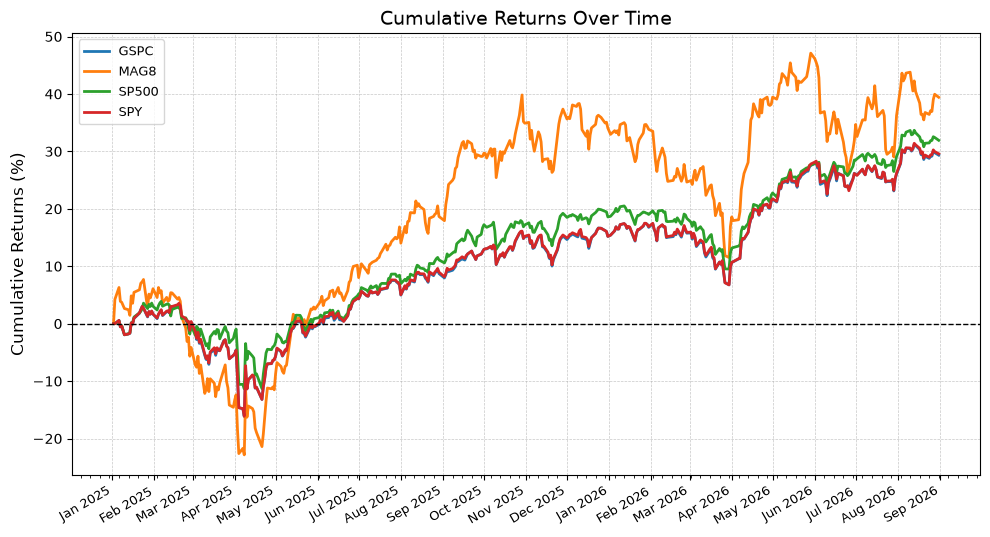

In [24]:
from analytics.performance import performance_analytics as perf

portfolio_short_names = ["SPY","SP500","MAG8","GSPC"]
portfolio_market_data = database.get_portfolio_market_data(session, engine, start_date, end_date, portfolio_short_names)
if data_source.lower() == "yahoo":
    portfolio_asset_returns = perf.calculate_portfolio_constituent_returns(portfolio_market_data, "adj_close")["returns"]
else:
    portfolio_asset_returns = perf.calculate_portfolio_constituent_returns(portfolio_market_data, "adj_close")["returns"]  
portfolio_asset_weights = perf.calculate_portfolio_constituent_weights(portfolio_market_data, "adj_close", "market_weighted", max_weight=0.10)
portfolio_return = (portfolio_asset_returns * portfolio_asset_weights).T.groupby(level=0).sum().T

portfolio_total_return = portfolio_asset_returns * portfolio_asset_weights
fig = perf.plot_cumulative_returns(portfolio_total_return.T.groupby(level=0).sum().T)
display(fig)  # render the chart inline in the notebook


#### Equal Weighted

Now lets calculate portfolio returns and weights using the equal weighting methodology.<br>

Understanding Equal Weighting vs. Market Cap</br>
In a market-cap-weighted index (like the standard S&P 500), a 1% move in Apple or Microsoft affects the index much more than a 1% move in a smaller company. In an equal-weighted index, every company has the same impact.

| Feature        | Market-Cap Weighted                          | Equal-Weighted                              |
|---------------|----------------------------------------------|---------------------------------------------|
| Risk Profile  | Concentrated in Mega-Caps                    | More diversified across mid/large caps      |
| Growth Driver | Driven by "Winners" (e.g., MAG8)             | Driven by broad market breadth              |
| Volatility    | Lower (usually)                              | Higher (if smaller caps are volatile)       |




[get_portfolio_market_data] dropped 17 duplicate market_data row(s) on (security_id, as_of_date)


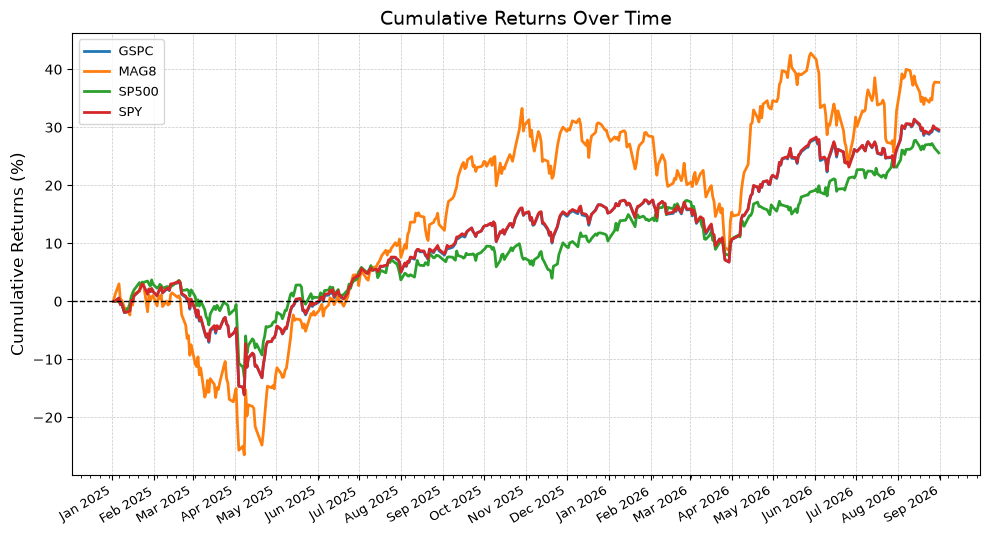

In [25]:
portfolio_short_names = ["SPY","SP500","MAG8","GSPC"]
portfolio_market_data = database.get_portfolio_market_data(session, engine, start_date, end_date, portfolio_short_names)
portfolio_asset_returns = perf.calculate_portfolio_constituent_returns(portfolio_market_data, "adj_close")["returns"]
portfolio_asset_weights = perf.calculate_portfolio_constituent_weights(portfolio_market_data, "adj_close", "equal_weighted")
portfolio_return = (portfolio_asset_returns * portfolio_asset_weights).T.groupby(level=0).sum().T

portfolio_total_return = portfolio_asset_returns * portfolio_asset_weights
fig = perf.plot_cumulative_returns(portfolio_total_return.T.groupby(level=0).sum().T)
display(fig)  # render the chart inline in the notebook


If you had held an equal-weighted version of the S&P 500 during this period

#### Mixed Weighted

Calculate portfolio returns and weights for MAG8 using equal weighting and for SP500 and SPY using market weighting. This approach provides a hybrid perspective on portfolio performance.

[get_portfolio_market_data] dropped 17 duplicate market_data row(s) on (security_id, as_of_date)


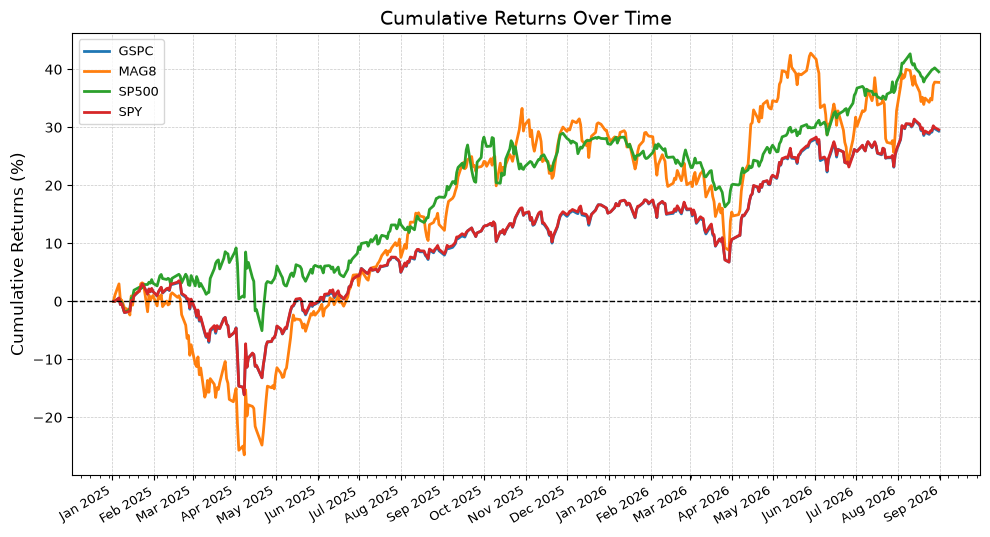

In [26]:
portfolio_short_names = ["SPY","SP500","MAG8","GSPC"]
portfolio_market_data = database.get_portfolio_market_data(session, engine, start_date, end_date, portfolio_short_names)
portfolio_asset_returns = perf.calculate_portfolio_constituent_returns(portfolio_market_data, "adj_close")["returns"]
portfolio_asset_weights = perf.calculate_portfolio_constituent_weights(portfolio_market_data, "adj_close", "market_weighted", portfolio_specific_weights={
        "MAG8": "equal_weighted"
    })
portfolio_return = (portfolio_asset_returns * portfolio_asset_weights).T.groupby(level=0).sum().T

portfolio_total_return = portfolio_asset_returns * portfolio_asset_weights
fig = perf.plot_cumulative_returns(portfolio_total_return.T.groupby(level=0).sum().T)
display(fig)  # render the chart inline in the notebook


[get_portfolio_market_data] dropped 17 duplicate market_data row(s) on (security_id, as_of_date)
Final cumulative return 2025:
  GSPC  :   29.34%
  SPY   :   29.58%
  SP500 :   31.93%
  MAG8  :   37.75%

SP500 vs GSPC  correlation: 0.936 (should be ~1 if reconstruction is correct)
SP500 vs MAG8  correlation: 0.835 (high => reconstruction is acting like MAG8)


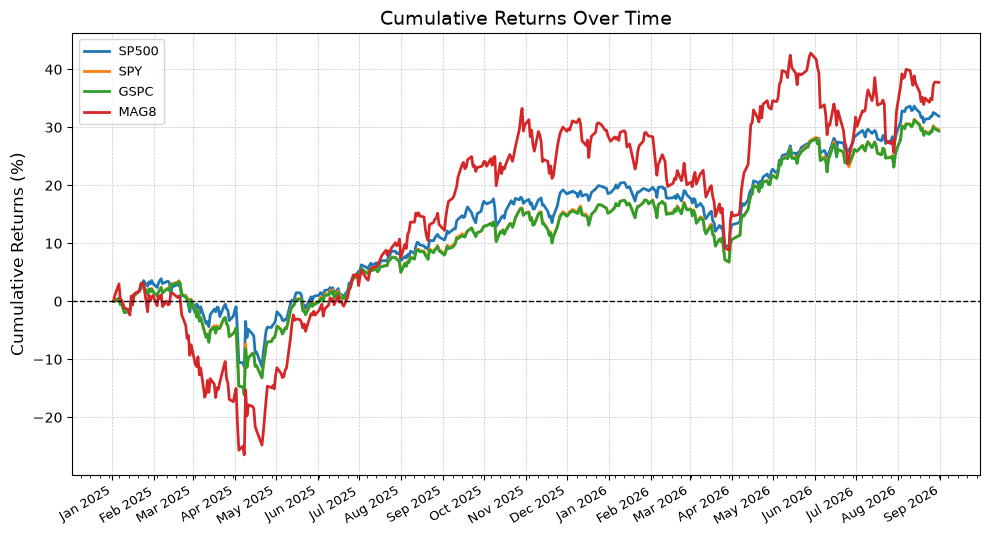

In [27]:
# --- S&P 500 reconstruction vs the REAL index (^GSPC) vs the MAG8 thesis ---
# This makes it easy to SEE why the reconstructed S&P 500 tracks MAG8 instead of ^GSPC.
from IPython.display import display
import numpy as np

portfolio_short_names = ["SPY", "SP500", "MAG8", "GSPC"]
pm_cmp = database.get_portfolio_market_data(session, engine, start_date, end_date, portfolio_short_names)
ret_cmp = perf.calculate_portfolio_constituent_returns(pm_cmp, "adj_close")["returns"]
wt_cmp = perf.calculate_portfolio_constituent_weights(
    pm_cmp, "adj_close", "market_weighted",
    portfolio_specific_weights={"MAG8": "equal_weighted"},
    max_weight=0.10,
)
ptr_cmp = ret_cmp * wt_cmp
# per-date portfolio return = sum across securities within each portfolio
daily = {p: ptr_cmp.xs(p, axis=1, level=0).sum(axis=1) for p in ptr_cmp.columns.get_level_values(0).unique()}
port_daily = pd.DataFrame(daily)
# Correct compounding for ARITHMETIC daily returns is (1+r).cumprod()-1.
# The prior exp(cumsum()) log-compounded arithmetic returns, which
# overstates higher-volatility series (the SP500 recon) vs the
# lower-vol ETF/index -- that was the source of the ~2x divergence.
cum = (1 + port_daily).cumprod() - 1

print("Final cumulative return 2025:")
for col in ["GSPC", "SPY", "SP500", "MAG8"]:
    if col in cum:
        print(f"  {col:6s}: {cum[col].iloc[-1]*100:7.2f}%")
if {"SP500", "GSPC", "MAG8"}.issubset(cum.columns):
    print(f"\nSP500 vs GSPC  correlation: {port_daily['SP500'].corr(port_daily['GSPC']):.3f} (should be ~1 if reconstruction is correct)")
    print(f"SP500 vs MAG8  correlation: {port_daily['SP500'].corr(port_daily['MAG8']):.3f} (high => reconstruction is acting like MAG8)")

# Plot reconstructed S&P 500 against the real index (^GSPC), the SPY ETF,
# and the MAG8 book -- all four on one chart so the reconstruction can be seen
# tracking the ETF/index directly. Uses properly-compounded cumulative returns
# (plot_cumulative_returns now compounds (1+r).cumprod(); passing the daily-return
# frame is fine). Include SPY so any residual gap to the tradable ETF is visible.
cmp_cols = [c for c in ["SP500", "SPY", "GSPC", "MAG8"] if c in port_daily.columns]
fig_cmp = perf.plot_cumulative_returns(port_daily[cmp_cols])
display(fig_cmp)


## 8. Portfolio Risk Analysis

The Mag8 portfolio shows the highest risk, with both historical and parametric VaR values significantly more negative than SPY and the reconstructed S&P 500. SPY sits in the middle, suggesting more concentration risk than the broader S&P 500, which has the lowest risk due to greater diversification. Parametric VaR is consistently more conservative than historical VaR across all three, possibly reflecting volatility clustering or heavier tails in return distributions. This difference is especially noticeable in Mag8, where parametric VaR nearly doubles historical VaR.

In [28]:
# --- SKIP VaR per user request (not needed for the S&P reconstruction work) ---
RUN_VAR = False
if RUN_VAR:
    # Calculate Portfolio Risk
    from analytics.risk import risk_analytics as risk
    max_date_index = portfolio_asset_weights.index.max()
    df_portfolio_var = []

    for PortfolioShortName in portfolio_short_names:
        portfolio_returns = portfolio_asset_returns[PortfolioShortName]
        portfolio_weights = portfolio_asset_weights[PortfolioShortName]
        portfolio_latest_weights = portfolio_asset_weights[max_date_index:max_date_index][PortfolioShortName]

        obj_risk = risk.PortfolioVaR(portfolio_asset_returns,
                                     portfolio_latest_weights,
                                     PortfolioShortName,
                                     lookback_days=24,
                                     horizon_days=1,
                                     confidence_interval=0.99)

        var_result = obj_risk.calculate_var()
        df_var = pd.DataFrame.from_dict(var_result, orient="columns")
        df_portfolio_var.append(df_var)

    df_combined_var = pd.concat(df_portfolio_var, keys=portfolio_short_names, ignore_index=False)
    df_combined_var